# L1 и L2 регуляризация

Это фундаментальные техники в машинном обучении, применяемые для борьбы с переобучением (overfitting) моделей, особенно линейных (линейная регрессия, логистическая регрессия), но также и в нейронных сетях.

Переобучение происходит, когда модель слишком хорошо подстраивается под обучающие данные, включая шум, и теряет способность обобщать на новые, невиданные данные. Регуляризация добавляет штраф к функции потерь модели за большие значения весов (коэффициентов).

**Основная идея:**
Модели с большими весами считаются более сложными. Сложные модели склонны к переобучению. Добавляя штраф за большие веса, мы заставляем модель искать баланс между минимизацией ошибки на обучающих данных и удержанием весов на низком уровне, что приводит к более простым и лучше обобщающим моделям.

**Функция потерь с регуляризацией:**
*Новая функция потерь = Исходная функция потерь + Коэффициент регуляризации ($\lambda$) * Штраф за веса*

$ \lambda $ (лямбда) — это гиперпараметр, который контролирует силу регуляризации. Большее значение $ \lambda $ означает более сильную регуляризацию (больший штраф за веса).

---

## L1 Регуляризация (Lasso - Least Absolute Shrinkage and Selection Operator)

*   **Формула штрафа:** $ \lambda \sum_{i=1}^{n} |w_i| $ (сумма абсолютных значений весов)
*   **Как работает:** Добавляет к функции потерь сумму модулей весов, умноженную на $ \lambda $.
*   **Эффект:**
    *   **Разреженность (Sparsity):** L1 регуляризация имеет свойство "обнулять" некоторые веса $ w_i $. Это означает, что она может полностью исключить некоторые признаки из модели.
    *   **Отбор признаков (Feature Selection):** Благодаря обнулению весов, L1 эффективно выполняет автоматический отбор наиболее важных признаков.
*   **Геометрическая интерпретация:** В пространстве весов ограничение L1 имеет форму ромба (или его многомерного аналога — гипероктаэдра). Оптимальное решение (точка касания эллипса уровня функции потерь и области ограничения) часто находится в "углах" ромба, которые лежат на осях координат. Это соответствует тому, что один или несколько весов равны нулю.
*   **Плюсы:**
    *   Автоматический отбор признаков.
    *   Создает более простые и интерпретируемые модели (меньше признаков).
    *   Полезна при работе с данными высокой размерности, где многие признаки могут быть нерелевантны.
*   **Минусы:**
    *   Может быть нестабильна при наличии сильно коррелирующих признаков (выбирает один из группы и обнуляет остальные случайным образом).
    *   Функция модуля не дифференцируема в нуле, что требует использования специальных методов оптимизации (например, субградиентный спуск).
*   **Когда использовать:** Когда предполагается, что многие признаки не важны, и требуется автоматический отбор признаков или получение разреженной, легко интерпретируемой модели.

---

## L2 Регуляризация (Ridge Regression / Weight Decay)

*   **Формула штрафа:** $ \lambda \sum_{i=1}^{n} w_i^2 $ (сумма квадратов весов)
*   **Как работает:** Добавляет к функции потерь сумму квадратов весов, умноженную на $ \lambda $.
*   **Эффект:**
    *   **Уменьшение весов (Weight Shrinkage / Decay):** L2 регуляризация штрафует большие веса сильнее (из-за квадрата), заставляя их уменьшаться, но редко обнуляет их полностью. Веса стремятся к нулю, но не достигают его.
    *   **Стабильность:** Делает решение более устойчивым, особенно при наличии мультиколлинеарности (сильной корреляции между признаками).
*   **Геометрическая интерпретация:** В пространстве весов ограничение L2 имеет форму круга (или его многомерного аналога — гиперсферы). Оптимальное решение находится в точке касания эллипса уровня функции потерь и сферы. Так как сфера гладкая и не имеет "углов" на осях (кроме как в начале координат), веса уменьшаются, но редко становятся точно нулевыми.
*   **Плюсы:**
    *   Более стабильна, чем L1, особенно при коррелирующих признаках.
    *   Имеет аналитическое решение в случае линейной регрессии.
    *   Функция штрафа дифференцируема везде, что упрощает оптимизацию.
    *   Часто дает лучшую предсказательную точность, когда большинство признаков вносят вклад.
*   **Минусы:**
    *   Не выполняет отбор признаков (оставляет все признаки в модели, хотя и с малыми весами).
    *   Модель может быть менее интерпретируемой из-за наличия всех признаков.
*   **Когда использовать:** Когда ожидается, что все (или большинство) признаков важны для модели. Когда есть мультиколлинеарность. Когда главная цель — улучшить обобщающую способность модели, а не отбор признаков.

---

**Сравнение L1 и L2**

| Характеристика         | L1 (Lasso)                               | L2 (Ridge)                               |
| :--------------------- | :--------------------------------------- | :--------------------------------------- |
| **Штраф**              | $ \lambda \sum |w_i| $                 | $ \lambda \sum w_i^2 $                 |
| **Эффект на веса**     | Обнуляет некоторые веса (разреженность)  | Уменьшает веса, не обнуляя их            |
| **Отбор признаков**    | Да                                       | Нет                                      |
| **Геометрия**          | Ромб / Гипероктаэдр                      | Круг / Гиперсфера                        |
| **Коррелир. признаки** | Нестабильна (выбирает один)              | Стабильна (уменьшает веса группы)        |
| **Дифференцируемость** | Нет в нуле                               | Да везде                                 |
| **Интерпретируемость** | Выше (меньше признаков)                  | Ниже (все признаки)                      |

---

## Elastic Net Регуляризация

*   Комбинирует L1 и L2 регуляризацию.
*   **Формула штрафа:** $ \lambda_1 \sum |w_i| + \lambda_2 \sum w_i^2 $
*   **Цель:** Объединить преимущества обоих методов: получить разреженность от L1 и стабильность L2, особенно при работе с группами коррелирующих признаков. L1 часть выполняет отбор признаков, а L2 часть стабилизирует этот отбор.
*   Требует настройки двух гиперпараметров ($ \lambda_1 $ и $ \lambda_2 $, или чаще $ \lambda $ и соотношения L1/L2).

---

## Практические аспекты и использование

1.  **Масштабирование признаков:** Перед применением регуляризации **крайне важно** масштабировать признаки (например, с помощью StandardScaler или MinMaxScaler). Регуляризация штрафует веса, и если признаки имеют разный масштаб, штраф будет применяться к ним неравномерно.
2.  **Выбор $ \lambda $:** Значение $ \lambda $ является гиперпараметром и подбирается с помощью методов кросс-валидации (Cross-Validation). Обычно пробуют ряд значений (например, по логарифмической шкале: 0.001, 0.01, 0.1, 1, 10, 100) и выбирают то, которое дает наилучшее качество на валидационной выборке.
3.  **Реализация:** Большинство библиотек ML (Scikit-learn, TensorFlow, PyTorch) имеют встроенные реализации моделей с L1, L2 и Elastic Net регуляризацией (например, `Lasso`, `Ridge`, `ElasticNet`, параметр `penalty` в `LogisticRegression`, `kernel_regularizer` в Keras/TensorFlow).

## Ключевые моменты для собеседования:

*   **Цель:** Борьба с переобучением, уменьшение сложности модели.
*   **Механизм:** Добавление штрафа к функции потерь за величину весов.
*   **L1 (Lasso):** Штраф - сумма модулей весов. Эффект - разреженность, отбор признаков. Геометрия - ромб.
*   **L2 (Ridge):** Штраф - сумма квадратов весов. Эффект - уменьшение весов, стабильность. Геометрия - круг/сфера.
*   **Elastic Net:** Комбинация L1 и L2.
*   **$ \lambda $:** Гиперпараметр, контролирующий силу регуляризации, подбирается кросс-валидацией.
*   **Важность масштабирования:** Обязательно перед применением.
*   **Когда что использовать:** L1 для отбора признаков и разреженности, L2 для стабильности и когда все признаки важны.

Истинные коэффициенты (первые 10 информативные, последние 5 - нет):
[16.75  0.    0.   63.64  0.   70.65  0.   10.46  3.16  0.    0.    0.
  0.    0.    0.  ]
------------------------------
Коэффициенты моделей:
Linear Regression: [12.59 -1.52  1.47 57.42  5.98 67.37  0.65  9.73  4.04 -0.09  0.96  4.3
 -1.7  -3.31  1.11]
Lasso (L1):        [11.56 -0.15  0.24 56.81  4.11 66.13  0.    7.7   2.93 -0.    0.    3.08
 -0.82 -2.36  0.81]
Ridge (L2):        [ 1.243e+01 -1.720e+00  1.770e+00  5.652e+01  5.740e+00  6.618e+01
  9.900e-01  9.600e+00  4.010e+00 -3.000e-02  9.400e-01  3.870e+00
 -1.730e+00 -3.410e+00  9.900e-01]
------------------------------


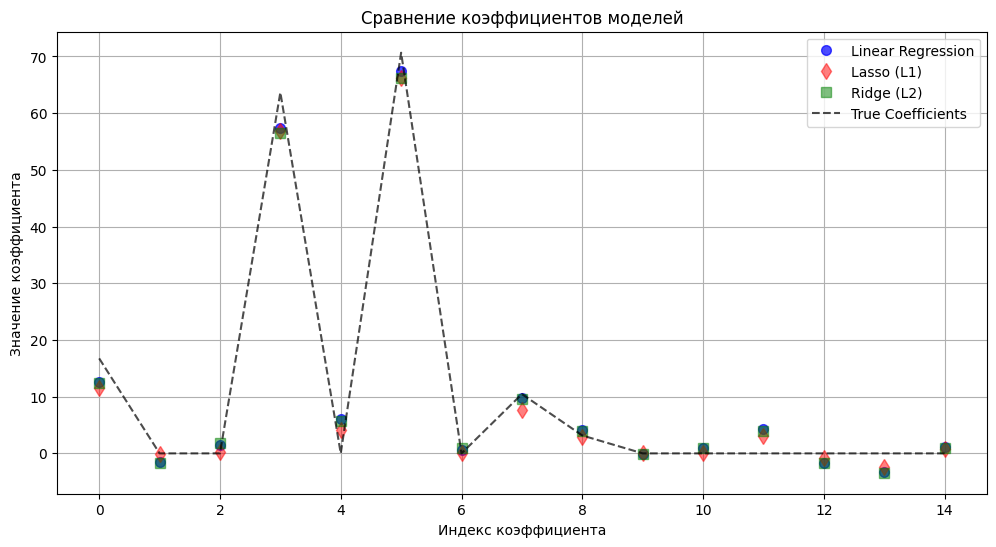

Оценка моделей на тестовой выборке (R^2):
Linear Regression: 0.936
Lasso (L1):        0.938
Ridge (L2):        0.934


In [1]:
## Мы создадим синтетический набор данных для регрессии, обучим три модели (обычную линейную регрессию, Lasso (L1) и Ridge (L2)) и сравним их коэффициенты.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression

# 1. Генерация синтетических данных
# Создадим 100 объектов с 10 признаками, из которых только 5 будут информативными.
# Добавим шум, чтобы регуляризация имела смысл.
X, y, true_coef = make_regression(
    n_samples=100,
    n_features=10,
    n_informative=5,
    noise=25,
    coef=True,  # Возвращает истинные коэффициенты
    random_state=42
)

# Добавим еще 5 нерелевантных признаков (просто шум)
X_non_relevant = np.random.rand(100, 5) * 10
X = np.hstack((X, X_non_relevant))

# Обновим true_coef, добавив нули для нерелевантных признаков
true_coef = np.hstack((true_coef, np.zeros(5)))

print("Истинные коэффициенты (первые 10 информативные, последние 5 - нет):")
print(np.round(true_coef, 2))
print("-" * 30)

# 2. Разделение данных и масштабирование
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Масштабирование признаков - ВАЖНО для регуляризации!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Обучение моделей
# Обычная линейная регрессия
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Lasso (L1 регуляризация)
# alpha - это аналог лямбды (коэффициент регуляризации)
lasso = Lasso(alpha=1.0, max_iter=10000)  # Увеличим max_iter для сходимости
lasso.fit(X_train_scaled, y_train)

# Ridge (L2 регуляризация)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

# 4. Сравнение коэффициентов
print("Коэффициенты моделей:")
print(f"Linear Regression: {np.round(lr.coef_, 2)}")
print(f"Lasso (L1):        {np.round(lasso.coef_, 2)}")
print(f"Ridge (L2):        {np.round(ridge.coef_, 2)}")
print("-" * 30)

# 5. Визуализация коэффициентов
plt.figure(figsize=(12, 6))
plt.plot(lr.coef_, alpha=0.7, linestyle='none', marker='o', markersize=7, color='blue', label='Linear Regression')
plt.plot(lasso.coef_, alpha=0.5, linestyle='none', marker='d', markersize=8, color='red', label='Lasso (L1)')
plt.plot(ridge.coef_, alpha=0.5, linestyle='none', marker='s', markersize=7, color='green', label='Ridge (L2)')
plt.plot(true_coef, alpha=0.7, linestyle='--', color='black', label='True Coefficients')  # Истинные коэф. для сравнения
plt.xlabel('Индекс коэффициента')
plt.ylabel('Значение коэффициента')
plt.title('Сравнение коэффициентов моделей')
plt.legend()
plt.grid(True)
plt.show()

# (Опционально) Сравнение производительности на тестовой выборке
print("Оценка моделей на тестовой выборке (R^2):")
print(f"Linear Regression: {lr.score(X_test_scaled, y_test):.3f}")
print(f"Lasso (L1):        {lasso.score(X_test_scaled, y_test):.3f}")
print(f"Ridge (L2):        {ridge.score(X_test_scaled, y_test):.3f}")

**Объяснение результатов:**

1.  **Генерация данных:** Мы создали данные, где часть признаков действительно влияет на целевую переменную (`n_informative=5`), а часть — нет (добавленные `X_non_relevant`). `true_coef` показывает, какие коэффициенты должны быть ненулевыми в идеальной модели.
2.  **Масштабирование:** `StandardScaler` приводит все признаки к одному масштабу (среднее 0, стандартное отклонение 1), что необходимо для корректной работы регуляризации.
3.  **Коэффициенты:**
    *   **Linear Regression:** Коэффициенты могут принимать большие значения, особенно для нерелевантных признаков, пытаясь подогнаться под шум в данных.
    *   **Lasso (L1):** Обратите внимание, что многие коэффициенты стали **равны нулю**. Lasso "выбрала" наиболее важные признаки и обнулила остальные, включая некоторые из изначально информативных (если их вклад был мал или они коррелировали с другими) и все нерелевантные. Это эффект **разреженности** и **отбора признаков**.
    *   **Ridge (L2):** Коэффициенты **уменьшились** по сравнению с линейной регрессией, но **не обнулились**. Ridge штрафует большие веса, делая их меньше, но сохраняет все признаки в модели.
4.  **Визуализация:** График наглядно показывает, как Lasso "схлопывает" многие коэффициенты до нуля, в то время как Ridge сжимает их к нулю, но не достигает его. Коэффициенты линейной регрессии без регуляризации часто имеют наибольшую амплитуду.
5.  **Оценка R^2:** В данном примере модели с регуляризацией (Lasso и Ridge) могут показать немного лучшую или сравнимую производительность на тестовых данных по сравнению с обычной линейной регрессией, так как они меньше переобучены на шум в обучающих данных. Результаты могут варьироваться в зависимости от `random_state` и параметра `alpha`.

Этот пример иллюстрирует ключевые различия в поведении L1 и L2 регуляризации применительно к весам модели.